In [1]:
%%capture
## [TEMPLATE BEGIN]
## おまじない：実行中のノートブック名からOUTPUT_DIRを決めるコード
from pathlib import Path
from IPython import get_ipython; ip = get_ipython()
if '__vsc_ipynb_file__' in ip.user_ns:
    ## VS Codeで実行されている場合
    THIS_NOTEBOOK_PATH = Path(ip.user_ns['__vsc_ipynb_file__'])
else:
    !pip install ipynbname
    import ipynbname; THIS_NOTEBOOK_PATH = Path(ipynbname.path())
    if "%2F" in THIS_NOTEBOOK_PATH.stem:
        ## Google Colabで実行されている場合
        colab_ip = %system hostname -I   # uses colab magic to get list from bash
        colab_ip = colab_ip[0].strip()   # returns "172.28.0.12"
        colab_port = 9000                # could use 6000, 8080, or 9000
        import requests
        filename = requests.get(f"http://{colab_ip}:{colab_port}/api/sessions").json()[0]["name"]
        THIS_NOTEBOOK_PATH = Path(filename)
    else:
        ## それ以外の場合
        THIS_NOTEBOOK_PATH = THIS_NOTEBOOK_PATH

OUTPUT_DIR = Path("figures") / THIS_NOTEBOOK_PATH.stem
## [TEMPLATE END]

In [2]:
print("File output directory:", OUTPUT_DIR)
# Create the output directory if it does not exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

File output directory: figures/_surrogate_losses


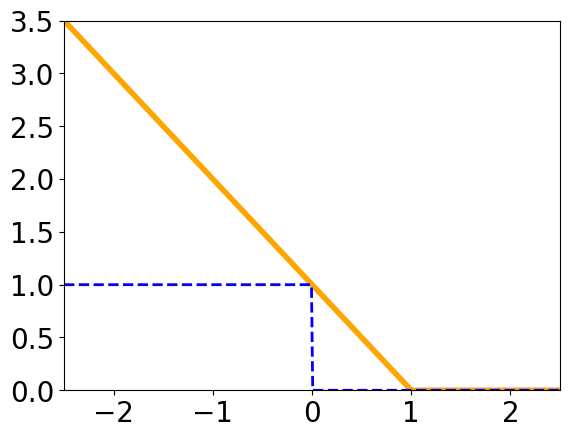

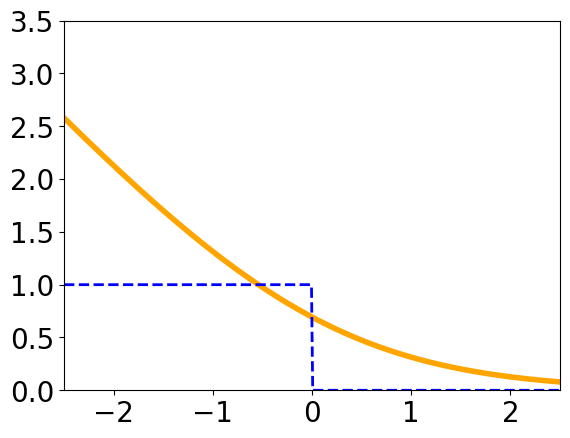

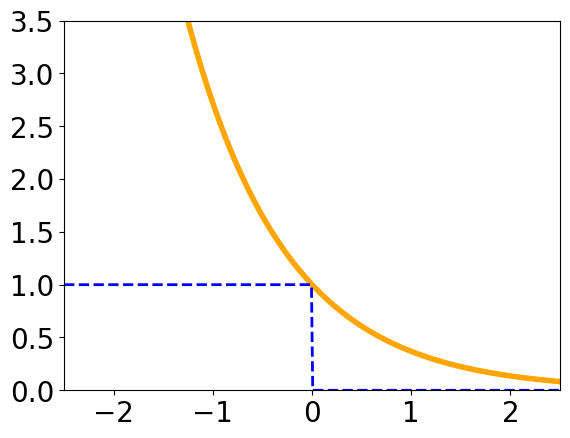

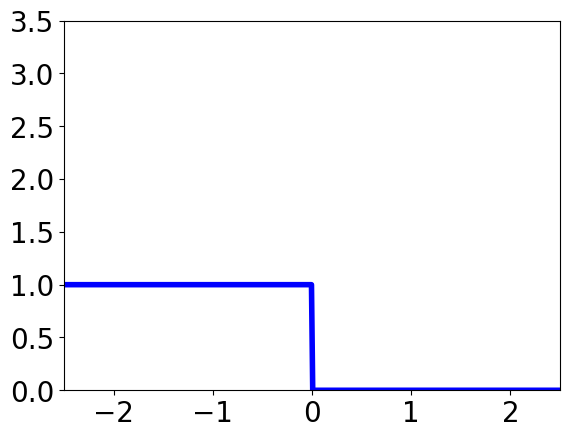

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range for m
m = np.linspace(-2.5, 2.5, 400)

# Define the loss functions
def hinge_loss(m):
    return np.maximum(0, 1 - m)

def logistic_loss(m):
    return np.log(1 + np.exp(-m))

def exponential_loss(m):
    return np.exp(-m)

def zero_one_loss(m):
    return np.where(m <= 0, 1, 0)

# Plot settings
line_width_main = 4  # Bolder main curves
line_width_zero_one = 2  # Thinner zero-one loss line

# Plot Hinge Loss with zero-one loss as dotted line
plt.figure()
plt.plot(m, hinge_loss(m), color='#FFA500', linewidth=line_width_main)
plt.plot(m, zero_one_loss(m), color='#0000FF', linestyle='--', linewidth=line_width_zero_one)
plt.xlim(-2.5, 2.5)
plt.ylim(0, 3.5)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.savefig(OUTPUT_DIR / "hinge_loss.png", bbox_inches='tight', pad_inches=0)
plt.show()

# Plot Logistic Loss with zero-one loss as dotted line
plt.figure()
plt.plot(m, logistic_loss(m), color='#FFA500', linewidth=line_width_main)
plt.plot(m, zero_one_loss(m), color='#0000FF', linestyle='--', linewidth=line_width_zero_one)
plt.xlim(-2.5, 2.5)
plt.ylim(0, 3.5)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.savefig(OUTPUT_DIR / "logistic_loss.png", bbox_inches='tight', pad_inches=0)
plt.show()

# Plot Exponential Loss with zero-one loss as dotted line
plt.figure()
plt.plot(m, exponential_loss(m), color='#FFA500', linewidth=line_width_main)
plt.plot(m, zero_one_loss(m), color='#0000FF', linestyle='--', linewidth=line_width_zero_one)
plt.xlim(-2.5, 2.5)
plt.ylim(0, 3.5)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.savefig(OUTPUT_DIR / "exponential_loss.png", bbox_inches='tight', pad_inches=0)
plt.show()

# Plot Zero-One Loss (standalone, in blue, bold)
plt.figure()
plt.plot(m, zero_one_loss(m), color='#0000FF', linewidth=line_width_main)
plt.xlim(-2.5, 2.5)
plt.ylim(0, 3.5)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.savefig(OUTPUT_DIR / "zero_one_loss.png", bbox_inches='tight', pad_inches=0)
plt.show()